# Exploratory Data Analysis (EDA)
---

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

import scipy.stats as stats

In [95]:
data = pd.read_csv('../data/processed/working_dataset.csv')
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


### Gender analysis
----

In [96]:
data['gender'].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

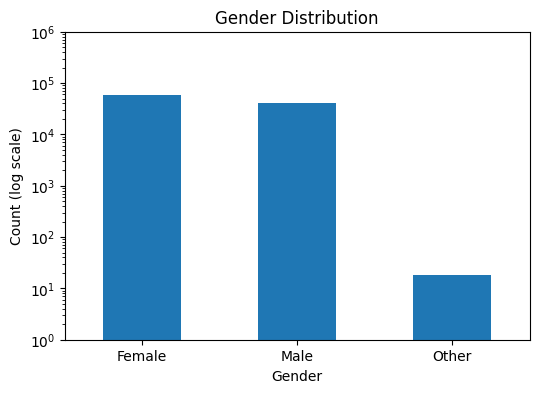

In [97]:
# Count the number of records for each gender category
gender_counts = data['gender'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 4))

# Plot the gender counts as a bar chart
gender_counts.plot(kind='bar')

# Apply logarithmic scale to the Y-axis.
# This is useful because the "Other" category has much fewer observations
# compared to "Female" and "Male".
plt.yscale('log')

# Set the Y-axis range from 1 to 1,000,000.
# Note: 10**6 = 1,000,000
plt.ylim(1, 10**6)

# Add chart title and axis labels
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count (log scale)')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)

# Save the figure
plt.savefig('../reports/figures/gender_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

### Age analysis
---

In [98]:
# Descriptive statistics for the age feature
data['age'].describe()

count    100000.000000
mean         41.885856
std          22.516840
min           0.080000
25%          24.000000
50%          43.000000
75%          60.000000
max          80.000000
Name: age, dtype: float64

- **Mean age:** Approximately **41 years**.
- **Age range:** Patients aged **0 to 80 years**.

- **25% (Q1):** First quartile (25% of the observations are below this value).
- **50% (Median):** Second quartile (50% of the observations are below this value).
- **75% (Q3):** Third quartile (75% of the observations are below this value).

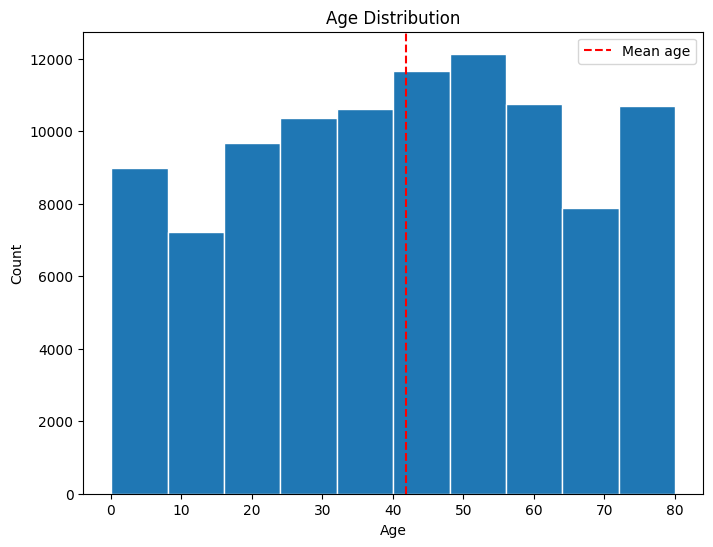

In [99]:
# Create a new figure with a fixed size
plt.figure(figsize=(8, 6))

# Plot the age distribution as a histogram
plt.hist(data['age'], edgecolor='white')

# Calculate the mean age
mean_age = data['age'].mean()

# Add a vertical dashed line showing the mean age
plt.axvline(mean_age, c='r', linestyle='--', label='Mean age')

# Add axis labels
plt.xlabel('Age')
plt.ylabel('Count')

# Display the legend
plt.legend()

# Add chart title
plt.title('Age Distribution')

plt.savefig('../reports/figures/age_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

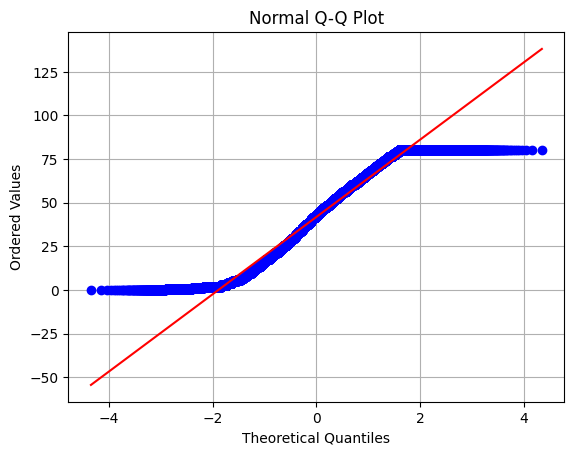

In [100]:
# Extract the age feature
age = data['age']

# Create a Q-Q (Quantile-Quantile) plot to assess whether
# the age distribution follows a normal distribution.
stats.probplot(age, dist="norm", plot=plt)

# Add chart title and axis labels
plt.title('Normal Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')

# Display grid lines for easier interpretation
plt.grid(True)

plt.savefig('../reports/figures/age_q_q_plot.png',
            dpi=300,
            bbox_inches='tight')

# Display the plot
plt.show()

### Conclusions

- The age feature does not follow a normal distribution.
- The central observations approximately follow the theoretical normal line.
- Significant deviations are observed in both tails of the distribution.
- The upper tail is truncated because the maximum recorded age is 80 years.
- Therefore, the age feature cannot be considered normally distributed.

### Hypertension analysisi
---

In [101]:
data['hypertension'].value_counts()

hypertension
0    92515
1     7485
Name: count, dtype: int64

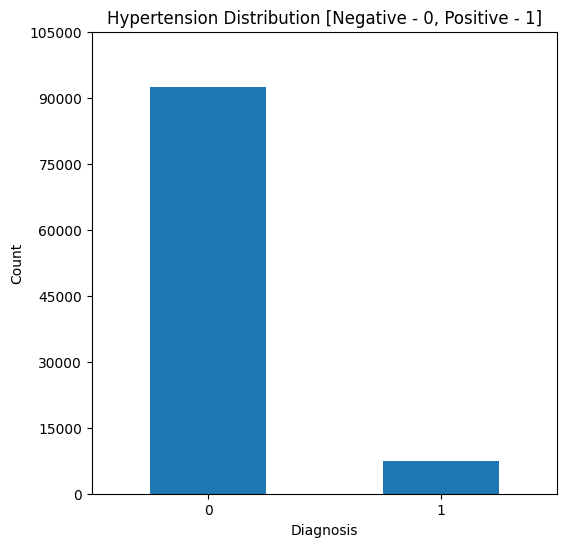

In [102]:

hypertension_counts = data['hypertension'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 6))

# Plot the gender counts as a bar chart
hypertension_counts.plot(kind='bar')


# Add chart title and axis labels
plt.title('Hypertension Distribution [Negative - 0, Positive - 1]')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)
plt.yticks(range(0, 110000, 15000))

# Save the figure
plt.savefig('../reports/figures/hypertension_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

### Heart disease analysis

In [103]:
data['heart_disease'].value_counts()

heart_disease
0    96058
1     3942
Name: count, dtype: int64

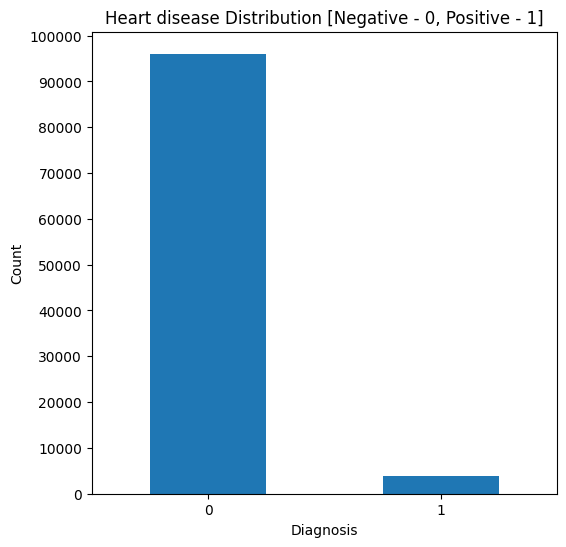

In [104]:
heart_disease_counts = data['heart_disease'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 6))

# Plot the gender counts as a bar chart
heart_disease_counts.plot(kind='bar')

# Add chart title and axis labels
plt.title('Heart disease Distribution [Negative - 0, Positive - 1]')
plt.xlabel('Diagnosis')
plt.ylabel('Count')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)
plt.yticks(range(0, 110000, 10000))

# Save the figure
plt.savefig('../reports/figures/heart_disease_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

### Smoking history analysis

In [105]:
data['smoking_history'].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

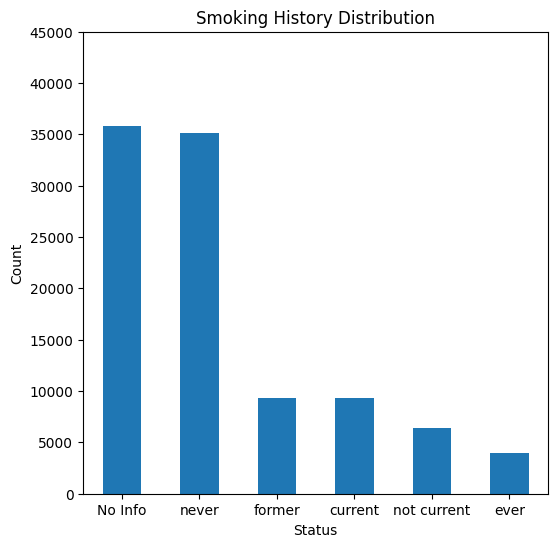

In [106]:
smoking_history_count = data['smoking_history'].value_counts()

# Create a new figure with a fixed size
plt.figure(figsize=(6, 6))

# Plot the gender counts as a bar chart
smoking_history_count.plot(kind='bar')


# Add chart title and axis labels
plt.title('Smoking History Distribution')
plt.xlabel('Status')
plt.ylabel('Count')

# Keep the X-axis labels horizontal
plt.xticks(rotation=0)
plt.yticks(range(0, 50000, 5000))

# Save the figure
plt.savefig('../reports/figures/smoking_history_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the chart
plt.show()

In [107]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


### Body mass index (BMI) analysis

In [108]:
data['bmi'].describe()

count    100000.000000
mean         27.320767
std           6.636783
min          10.010000
25%          23.630000
50%          27.320000
75%          29.580000
max          95.690000
Name: bmi, dtype: float64

## BMI (Body Mass Index)
---
BMI (Body Mass Index) is a measure used to assess whether a person's weight is within a healthy range relative to their height.

### Categories

BMI Category

< 18.5  Underweight

18.5 – 24.9 Normal weight

25.0 – 29.9  Overweight

\>= 30.0 - Obesity

**Note:** BMI is a quick screening tool for assessing body weight, but it does not account for muscle mass, age, sex, or body fat percentage.

In [109]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


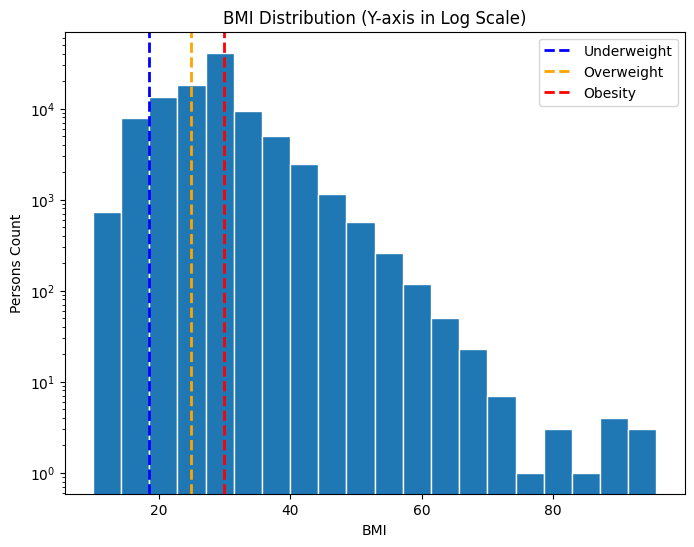

In [110]:
# Create a figure with a custom size.
plt.figure(figsize=(8, 6))

# Plot the distribution of BMI values using a histogram.
plt.hist(data['bmi'], bins=20, edgecolor='white')

# Apply logarithmic scale to the Y-axis to better visualize small and large counts.
plt.yscale('log')

# Add vertical reference lines for the main BMI category thresholds.
plt.axvline(18.5, color='blue', linestyle='--', linewidth=2, label='Underweight')
plt.axvline(25, color='orange', linestyle='--', linewidth=2, label='Overweight')
plt.axvline(30, color='red', linestyle='--', linewidth=2, label='Obesity')

# Add labels, legend, and title.
plt.xlabel('BMI')
plt.ylabel('Persons Count')
plt.legend()
plt.title('BMI Distribution (Y-axis in Log Scale)')

# Save the figure
plt.savefig('../reports/figures/bmi_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the plot.
plt.show()

### Conclusions

The BMI distribution shows that most individuals are concentrated in the normal and overweight ranges.

A smaller number of individuals fall into the underweight category, while higher BMI values above 30 indicate the presence of obese individuals in the dataset.

The Y-axis is displayed on a logarithmic scale, which makes it easier to visualize both frequent and rare BMI values.

Overall, the dataset contains a wide range of BMI values, but the main concentration appears around the healthy-to-overweight BMI interval.

In [111]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


### HbA1c_level analysis
---
Glycated Hemoglobin (HbA1c) level expressed as a percentage. It reflects the patient's average blood glucose level over the previous 2–3 months

In [112]:
data['HbA1c_level'].describe()

count    100000.000000
mean          5.527507
std           1.070672
min           3.500000
25%           4.800000
50%           5.800000
75%           6.200000
max           9.000000
Name: HbA1c_level, dtype: float64

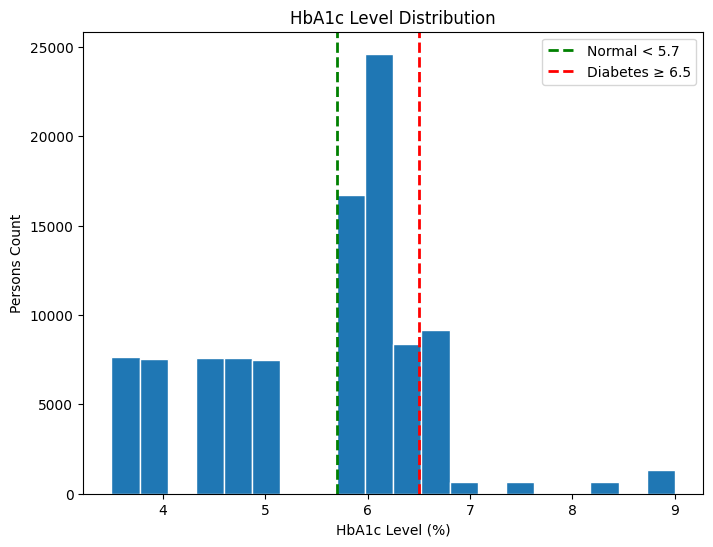

In [113]:
# Create a figure with a custom size.
plt.figure(figsize=(8, 6))

# Plot the distribution of HbA1c values using a histogram.
plt.hist(data['HbA1c_level'], bins=20, edgecolor='white')

# Add vertical reference lines for HbA1c categories.
plt.axvline(5.7, color='green', linestyle='--', linewidth=2, label='Normal < 5.7')
plt.axvline(6.5, color='red', linestyle='--', linewidth=2, label='Diabetes ≥ 6.5')

# Add labels, legend, and title.
plt.xlabel('HbA1c Level (%)')
plt.ylabel('Persons Count')
plt.legend()
plt.title('HbA1c Level Distribution')

# Save the figure.
plt.savefig('../reports/figures/HbA1c_level_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the plot.
plt.show()

### Conclusions

The HbA1c level distribution is concentrated between **5.7% and 6.5%**, indicating that a large proportion of individuals fall within the **prediabetes** range.

A noticeable number of observations have HbA1c values **above 6.5%**, suggesting the presence of individuals with diabetes.

Only a relatively small proportion of individuals have HbA1c levels below **5.7%**, which corresponds to the normal range.


In [114]:
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


### Blood glucose level analysis
---
Current blood glucose concentration measured in **mg/dL**. Higher values may indicate impaired glucose regulation or diabetes.

In [115]:
data['blood_glucose_level'].describe()

count    100000.000000
mean        138.058060
std          40.708136
min          80.000000
25%         100.000000
50%         140.000000
75%         159.000000
max         300.000000
Name: blood_glucose_level, dtype: float64

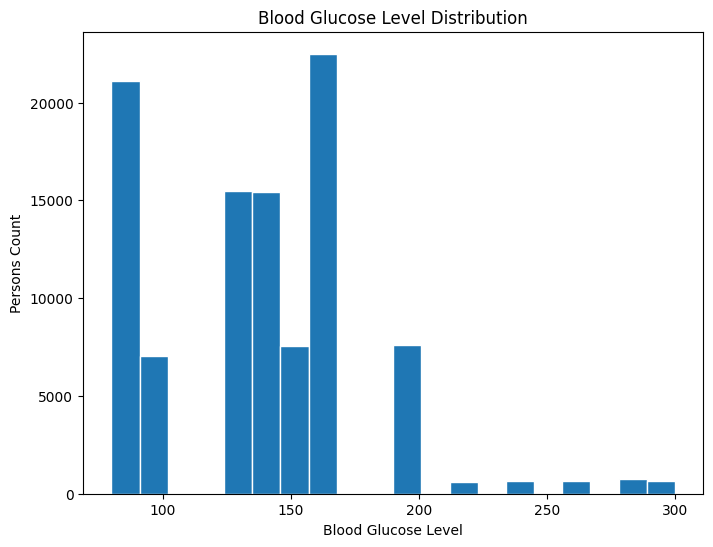

In [116]:
# Create a figure with a custom size.
plt.figure(figsize=(8, 6))

# Plot the distribution of blood glucose levels using a histogram.
plt.hist(data['blood_glucose_level'], bins=20, edgecolor='white')

# Add axis labels and chart title.
plt.xlabel('Blood Glucose Level')
plt.ylabel('Persons Count')
plt.title('Blood Glucose Level Distribution')

# Save the figure.
plt.savefig('../reports/figures/blood_glucose_level_distribution.png',
            dpi=300,
            bbox_inches='tight')

# Display the plot.
plt.show()

### Conclusions

The blood glucose level distribution shows several clear peaks, which means the values are not fully continuous but appear to be recorded at specific levels.

Most individuals are concentrated between approximately **80 and 160**, with the highest concentration around **150–160**.

There are also values above **200**, including some extreme values close to **300**, which may indicate individuals with very high blood glucose levels.